# 02: Data Quality

### Freight Rate Prediction 

The **Purpose of this notebook** is to find every defect in the data, prove what each one is, decide how
to fix it, and produce a cleaning function that the production pipeline will use.

I will work through five questions:

1. What is missing?
2. What is duplicated?
3. What is impossible? (values that cannot exist in the real world)
4. What is implausible? (values that could exist but almost certainly did not)
5. Are the same defects present in the data we must predict?

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.color": "#D9E2E4",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

ACCENT = "#064A56"
FLAG = "#C0392B"

DATA = Path("../data")
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", bbox_inches="tight", dpi=150)

train = pd.read_csv(DATA / "train-test.csv", parse_dates=["date"])
val = pd.read_csv(DATA / "validation.csv", parse_dates=["date"])
dec = pd.read_csv(DATA / "december-chart-inputs.csv", parse_dates=["date"])

print(f"train {train.shape} | validation {val.shape} | december {dec.shape}")

train (48000, 14) | validation (12000, 13) | december (31, 7)


collect every issue i find into one register, and print it at the end as the
audit trail for the report.

In [3]:
ISSUES = []

def log_issue(name, severity, n_train, n_val, evidence, treatment):
    ISSUES.append({
        "issue": name,
        "severity": severity,
        "rows_train": n_train,
        "rows_val": n_val,
        "evidence": evidence,
        "treatment": treatment,
    })

print("Issue register initialised.")

Issue register initialised.


### Missing Value Check

In [4]:
missing = pd.DataFrame({
    "train_n": train.isna().sum(),
    "train_pct": (train.isna().mean() * 100).round(2),
    "val_n": val.reindex(columns=train.columns).isna().sum(),
    "val_pct": (val.reindex(columns=train.columns).isna().mean() * 100).round(2),
})
missing[missing[["train_n", "val_n"]].sum(axis=1) > 0]

,train_n,train_pct,val_n,val_pct
weight,300,0.62,165,1.38
market_index,374,0.78,249,2.08
posted_rate,0,0.00,12000,100.00


In [5]:
rpm = train["posted_rate"] / train["distance"]
sane = rpm.between(1.0, 4.0)

for col in ["weight", "market_index"]:
    gap = train[col].isna()
    print(f"--- {col} ---")
    print(f"  rows missing        : {gap.sum():,}")
    print(f"  mean RPM when present: {rpm[sane & ~gap].mean():.3f}")
    print(f"  mean RPM when missing: {rpm[sane & gap].mean():.3f}")
    print(f"  equipment mix when missing: "
          f"{train.loc[gap, 'equipment'].value_counts(normalize=True).round(2).to_dict()}")
    print()

print(f"Overall equipment mix: "
      f"{train['equipment'].value_counts(normalize=True).round(2).to_dict()}")

--- weight ---
  rows missing        : 300
  mean RPM when present: 2.187
  mean RPM when missing: 2.172
  equipment mix when missing: {'Dry Van': 0.58, 'Reefer': 0.23, 'Flatbed': 0.18}

--- market_index ---
  rows missing        : 374
  mean RPM when present: 2.186
  mean RPM when missing: 2.184
  equipment mix when missing: {'Dry Van': 0.54, 'Reefer': 0.26, 'Flatbed': 0.2}

Overall equipment mix: {'Dry Van': 0.57, 'Reefer': 0.25, 'Flatbed': 0.18}


### Missing values treatment

In [6]:
log_issue("Missing weight", "Low", int(train["weight"].isna().sum()),
          int(val["weight"].isna().sum()),
          "0.6% of rows; RPM and equipment mix identical to non-missing rows",
          "Impute with median weight per equipment type")

log_issue("Missing market_index", "Low", int(train["market_index"].isna().sum()),
          int(val["market_index"].isna().sum()),
          "0.8% of rows; missing at random",
          "Impute with median; feature dropped from model regardless")
print("Logged.")

Logged.


### Duplicates Checks

In [7]:
print(f"Fully identical rows        : {train.duplicated().sum()}")
print(f"Repeated load_id            : {train['load_id'].duplicated().sum()}")
print(f"Identical features, any rate: "
      f"{train.drop(columns=['load_id', 'posted_rate']).duplicated().sum()}")
print()
print(f"Validation repeated load_id : {val['load_id'].duplicated().sum()}")
print(f"Validation row count        : {len(val):,} (scorer requires exactly 12,000)")

Fully identical rows        : 0
Repeated load_id            : 0
Identical features, any rate: 0

Validation repeated load_id : 0
Validation row count        : 12,000 (scorer requires exactly 12,000)


### Impossible Values Checks - Negative Weight

In [8]:
neg = train["weight"] < 0
print(f"Negative weights in training  : {neg.sum()}")
print(f"Negative weights in validation: {(val['weight'] < 0).sum()}")
print(f"Zero weights                  : {(train['weight'] == 0).sum()}")
print(f"\nRange of negative values: {train.loc[neg, 'weight'].min():,.0f} "
      f"to {train.loc[neg, 'weight'].max():,.0f}")
print(f"Range of positive values: {train.loc[train['weight'] > 0, 'weight'].min():,.0f} "
      f"to {train.loc[train['weight'] > 0, 'weight'].max():,.0f}")

Negative weights in training  : 292
Negative weights in validation: 145
Zero weights                  : 0

Range of negative values: -47,500 to -5,000
Range of positive values: 5,000 to 47,500


In [9]:
flipped = train.loc[neg, "weight"].abs()
valid = train.loc[train["weight"] > 0, "weight"]

comparison = pd.DataFrame({
    "flipped_negatives": flipped.describe(),
    "valid_weights": valid.describe(),
}).round(1)
print(comparison)

       flipped_negatives  valid_weights
count              292.0        47408.0
mean             31724.2        31415.4
std               8262.5         7994.9
min               5000.0         5000.0
25%              25928.5        25922.0
50%              31821.5        31493.5
75%              37284.2        37063.0
max              47500.0        47500.0


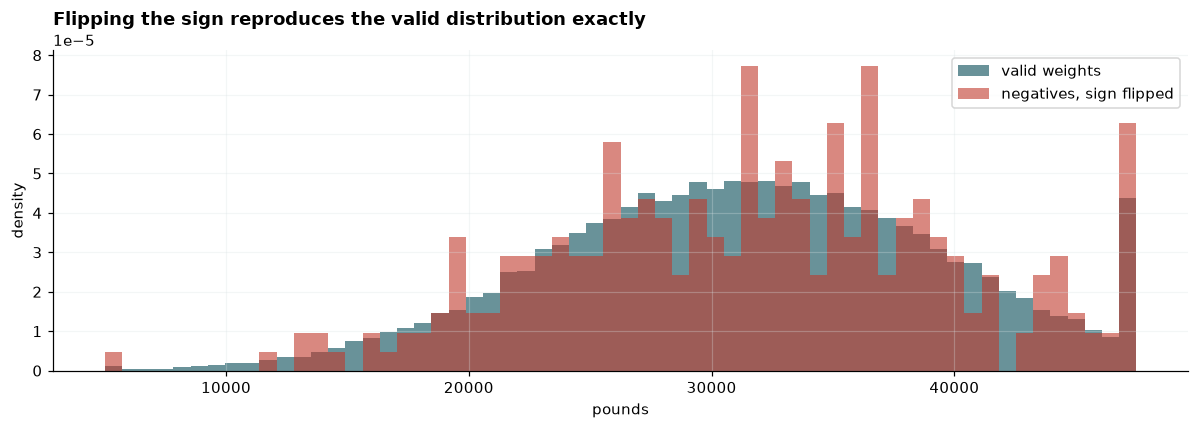

In [10]:
plt.figure(figsize=(11, 4))
plt.hist(valid, bins=60, alpha=0.6, color=ACCENT, density=True, label="valid weights")
plt.hist(flipped, bins=60, alpha=0.6, color=FLAG, density=True, label="negatives, sign flipped")
plt.title("Flipping the sign reproduces the valid distribution exactly",
          loc="left", fontweight="bold")
plt.xlabel("pounds"); plt.ylabel("density")
plt.legend()
save("02_negative_weight")
plt.show()

### Negative Sign Treatment

In [11]:
log_issue("Negative weight", "High", int(neg.sum()), int((val["weight"] < 0).sum()),
          "Bounds identical to valid weights (5,000-47,500); distributions overlay",
          "Take absolute value — recovers the true weight")
print("Logged.")

Logged.


### Check if corrupted rows are targeted or random

In [12]:
print("Equipment mix of corrupted rows vs overall:")
print(pd.DataFrame({
    "corrupted": train.loc[neg, "equipment"].value_counts(normalize=True),
    "overall": train["equipment"].value_counts(normalize=True),
}).round(3))

print("\nCorrupted rows per month:")
print(train.loc[neg, "date"].dt.month.value_counts().sort_index().to_string())

Equipment mix of corrupted rows vs overall:
           corrupted  overall
equipment                    
Dry Van        0.531    0.567
Flatbed        0.240    0.182
Reefer         0.229    0.251

Corrupted rows per month:
date
1     31
2     30
3     40
4     25
5     40
6     30
7     22
8     15
9     26
10    33


### Plausibility of the remaining weights

Beyond the sign, are the weights themselves sensible for road freight?

In [13]:
w = train["weight"].abs()
print(w.describe(percentiles=[.01, .25, .5, .75, .99]).round(0))
print(f"\nBelow 1,000 lb : {(w < 1_000).sum()}")
print(f"Above 48,000 lb: {(w > 48_000).sum()}")

count    47700.0
mean     31417.0
std       7997.0
min       5000.0
1%       12478.0
25%      25922.0
50%      31496.0
75%      37063.0
99%      47500.0
max      47500.0
Name: weight, dtype: float64

Below 1,000 lb : 0
Above 48,000 lb: 0


### Distance and coordinates

`distance` is the strongest predictor, so it deserves scrutiny. So i will verify that the
coordinate columns are internally consistent.

In [14]:
print(train["distance"].describe(percentiles=[.01, .5, .99]).round(1))
print(f"\nZero or negative distances: {(train['distance'] <= 0).sum()}")
print(f"Minimum distance          : {train['distance'].min()}")
print(f"Loads where pickup == delivery: {(train['pickup'] == train['delivery']).sum()}")

count    48000.0
mean      1135.9
std        728.6
min         70.0
1%         121.9
50%        953.3
99%       3029.3
max       3439.8
Name: distance, dtype: float64

Zero or negative distances: 0
Minimum distance          : 70.0
Loads where pickup == delivery: 0


In [16]:
# Check Coordinate Consistency

for role in ["pickup", "delivery"]:
    counts = train.groupby(role)[[f"{role}_lat", f"{role}_lon"]].nunique()
    print(f"{role}: cities with more than one coordinate -> "
          f"{(counts > 1).sum().to_dict()}")

# Same city seen as origin and as destination must agree.
origins = (train[["pickup", "pickup_lat", "pickup_lon"]].drop_duplicates()
           .rename(columns={"pickup": "city", "pickup_lat": "lat", "pickup_lon": "lon"}))
dests = (train[["delivery", "delivery_lat", "delivery_lon"]].drop_duplicates()
         .rename(columns={"delivery": "city", "delivery_lat": "lat", "delivery_lon": "lon"}))
merged = origins.merge(dests, on="city", suffixes=("_o", "_d"))
mismatch = (~np.isclose(merged["lat_o"], merged["lat_d"])).sum() + \
           (~np.isclose(merged["lon_o"], merged["lon_d"])).sum()
print(f"\nCities whose origin and destination coordinates disagree: {mismatch}")

pickup: cities with more than one coordinate -> {'pickup_lat': 0, 'pickup_lon': 0}
delivery: cities with more than one coordinate -> {'delivery_lat': 0, 'delivery_lon': 0}

Cities whose origin and destination coordinates disagree: 0


In [17]:
# Check if distance is consistent with coordinates

def haversine_miles(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles between two coordinate pairs."""
    R = 3958.8
    p1, l1, p2, l2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin((l2 - l1) / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

train["great_circle"] = haversine_miles(
    train["pickup_lat"], train["pickup_lon"],
    train["delivery_lat"], train["delivery_lon"],
)
train["circuity"] = train["distance"] / train["great_circle"]

print(f"Correlation distance vs great-circle: "
      f"{train[['distance', 'great_circle']].corr().iloc[0, 1]:.4f}")
print()
print(train["circuity"].describe(percentiles=[.01, .5, .99]).round(3))

Correlation distance vs great-circle: 0.9995

count    48000.000
mean         1.195
std          0.144
min          1.058
1%           1.130
50%          1.182
99%          1.404
max          9.635
Name: circuity, dtype: float64


### Implausible rates

Now the most consequential check: the target itself.

In [18]:
train["rate_per_mile"] = train["posted_rate"] / train["distance"]

print(train["rate_per_mile"]
      .describe(percentiles=[.001, .01, .05, .5, .95, .99, .999]).round(3))

count    48000.000
mean         2.215
std          0.584
min          0.334
0.1%         0.437
1%           1.674
5%           1.808
50%          2.145
95%          2.736
99%          3.177
99.9%       10.069
max         14.125
Name: rate_per_mile, dtype: float64


In [19]:
LOWER, UPPER = 1.0, 4.0
too_high = train["rate_per_mile"] > UPPER
too_low = train["rate_per_mile"] < LOWER
corrupt = too_high | too_low

baseline = train.loc[~corrupt, "rate_per_mile"].median()

print(f"Baseline (median RPM of clean rows): ${baseline:.3f}/mile\n")
print(f"Inflated rates (> ${UPPER:.2f}/mile): {too_high.sum():,} rows")
print(f"  median ${train.loc[too_high, 'rate_per_mile'].median():.2f}/mile "
      f"= {train.loc[too_high, 'rate_per_mile'].median() / baseline:.1f}x baseline")
print(f"  max    ${train.loc[too_high, 'rate_per_mile'].max():.2f}/mile\n")
print(f"Deflated rates (< ${LOWER:.2f}/mile): {too_low.sum():,} rows")
print(f"  median ${train.loc[too_low, 'rate_per_mile'].median():.2f}/mile "
      f"= {train.loc[too_low, 'rate_per_mile'].median() / baseline:.2f}x baseline")
print(f"  min    ${train.loc[too_low, 'rate_per_mile'].min():.2f}/mile\n")
print(f"Total affected: {corrupt.sum():,} rows ({corrupt.mean()*100:.2f}%)")

Baseline (median RPM of clean rows): $2.145/mile

Inflated rates (> $4.00/mile): 340 rows
  median $7.51/mile = 3.5x baseline
  max    $14.13/mile

Deflated rates (< $1.00/mile): 329 rows
  median $0.61/mile = 0.28x baseline
  min    $0.33/mile

Total affected: 669 rows (1.39%)


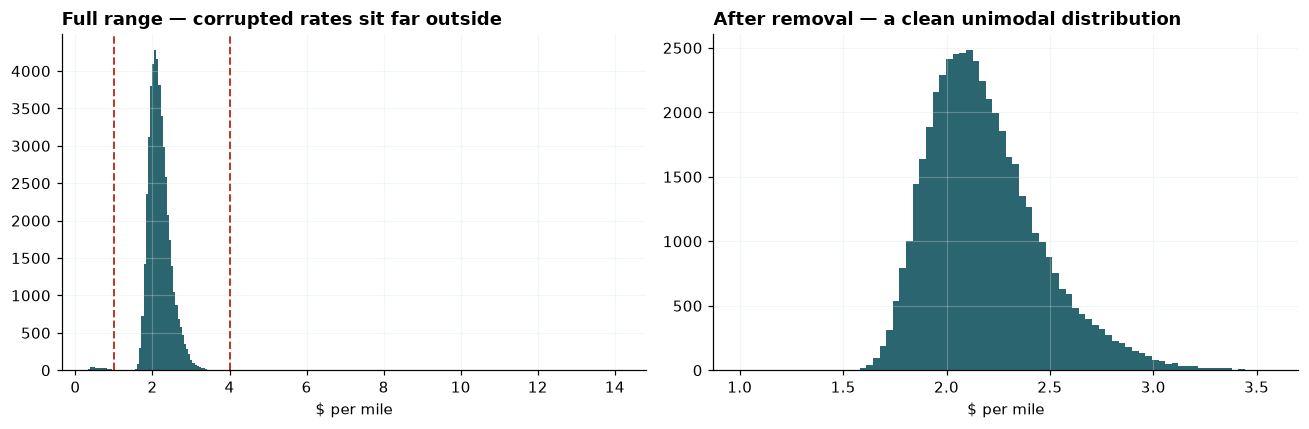

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train["rate_per_mile"], bins=250, color=ACCENT, alpha=0.85)
axes[0].axvline(LOWER, color=FLAG, ls="--", lw=1.3)
axes[0].axvline(UPPER, color=FLAG, ls="--", lw=1.3)
axes[0].set_title("Full range — corrupted rates sit far outside", loc="left", fontweight="bold")
axes[0].set_xlabel("$ per mile")

axes[1].hist(train.loc[~corrupt, "rate_per_mile"], bins=80, color=ACCENT, alpha=0.85)
axes[1].set_title("After removal — a clean unimodal distribution",
                  loc="left", fontweight="bold")
axes[1].set_xlabel("$ per mile")
save("02_rate_outliers")
plt.show()

In [21]:
log_issue("Inflated rates", "High", int(too_high.sum()), 0,
          f"340 rows at ~3.5x baseline RPM, max ${train.loc[too_high,'rate_per_mile'].max():.1f}/mi",
          "Drop from training only — target unavailable at prediction time")

log_issue("Deflated rates", "High", int(too_low.sum()), 0,
          f"329 rows at ~0.28x baseline RPM, min ${train.loc[too_low,'rate_per_mile'].min():.2f}/mi",
          "Drop from training only")
print("Logged.")

Logged.


In [22]:
print("Equipment mix — corrupted vs overall:")
print(pd.DataFrame({
    "corrupted": train.loc[corrupt, "equipment"].value_counts(normalize=True),
    "overall": train["equipment"].value_counts(normalize=True),
}).round(3))

print("\nCorrupted rows per month:")
print(train.loc[corrupt, "date"].dt.month.value_counts().sort_index().to_string())

print(f"\nRows with BOTH a bad rate and a negative weight: "
      f"{(corrupt & (train['weight'] < 0)).sum()}")

Equipment mix — corrupted vs overall:
           corrupted  overall
equipment                    
Dry Van        0.547    0.567
Reefer         0.266    0.251
Flatbed        0.187    0.182

Corrupted rows per month:
date
1     81
2     55
3     71
4     66
5     61
6     61
7     65
8     66
9     64
10    79

Rows with BOTH a bad rate and a negative weight: 9


In [23]:
checks = pd.DataFrame({
    "train": {
        "rows": len(train),
        "missing weight": int(train["weight"].isna().sum()),
        "negative weight": int((train["weight"] < 0).sum()),
        "missing market_index": int(train["market_index"].isna().sum()),
        "duplicate ids": int(train["load_id"].duplicated().sum()),
    },
    "validation": {
        "rows": len(val),
        "missing weight": int(val["weight"].isna().sum()),
        "negative weight": int((val["weight"] < 0).sum()),
        "missing market_index": int(val["market_index"].isna().sum()),
        "duplicate ids": int(val["load_id"].duplicated().sum()),
    },
})
print(checks)

print("\n--- december_chart_inputs.csv ---")
print(f"rows            : {len(dec)} (scorer requires 31)")
print(f"missing values  : {int(dec.isna().sum().sum())} "
      f"(predicted_rate is expected to be empty)")
print(f"negative weight : {int((dec['weight'] < 0).sum())}")

                      train  validation
rows                  48000       12000
missing weight          300         165
negative weight         292         145
missing market_index    374         249
duplicate ids             0           0

--- december_chart_inputs.csv ---
rows            : 31 (scorer requires 31)
missing values  : 31 (predicted_rate is expected to be empty)
negative weight : 0


### Treatment Strategy

In [24]:
register = pd.DataFrame(ISSUES)
register.index = range(1, len(register) + 1)
register

,issue,severity,rows_train,rows_val,evidence,treatment
1,Missing weight,Low,300,165,0.6% of rows; RPM and equipment mix identical ...,Impute with median weight per equipment type
2,Missing market_index,Low,374,249,0.8% of rows; missing at random,Impute with median; feature dropped from model...
3,Negative weight,High,292,145,"Bounds identical to valid weights (5,000-47,50...",Take absolute value — recovers the true weight
4,Inflated rates,High,340,0,"340 rows at ~3.5x baseline RPM, max $14.1/mi",Drop from training only — target unavailable a...
5,Deflated rates,High,329,0,"329 rows at ~0.28x baseline RPM, min $0.33/mi",Drop from training only


### The cleaning function

This is the prototype that will become `src/data/cleaning.py`.

In [25]:
RPM_LOWER = 1.0
RPM_UPPER = 4.0


def clean_loads(df, *, is_training, weight_medians=None):
    """Apply all data-quality fixes established in this notebook.

    Parameters
    ----------
    df : DataFrame
        Raw loads, from train_test.csv or validation.csv.
    is_training : bool
        When True, rows with corrupted rates are dropped. Must be False at
        prediction time — we owe a rate for every load.
    weight_medians : Series, optional
        Median weight per equipment type, learned on training data. Passing the
        training values at prediction time prevents leakage from the scoring set.

    Returns
    -------
    (DataFrame, Series)
        Cleaned frame, and the weight medians used.
    """
    out = df.copy()

    # 1. Sign flip — recover the true weight rather than losing the row.
    out["weight"] = out["weight"].abs()

    # 2. Impute missing weight using medians learned from training data only.
    if weight_medians is None:
        weight_medians = out.groupby("equipment")["weight"].median()
    out["weight"] = out["weight"].fillna(out["equipment"].map(weight_medians))
    out["weight"] = out["weight"].fillna(weight_medians.median())

    # 3. Impute market_index. Retained for pipeline completeness; the feature is
    #    excluded from the model because december_chart_inputs.csv lacks it.
    if "market_index" in out.columns:
        out["market_index"] = out["market_index"].fillna(out["market_index"].median())

    # 4. Drop corrupted rates. Training only — there is no target to check at
    #    prediction time, and every validation load must receive a rate.
    if is_training:
        rpm = out["posted_rate"] / out["distance"]
        keep = rpm.between(RPM_LOWER, RPM_UPPER)
        out = out[keep].reset_index(drop=True)

    return out, weight_medians

#### Verify if function works

In [26]:
train_clean, medians = clean_loads(train.drop(columns=["great_circle", "circuity",
                                                       "rate_per_mile"]),
                                   is_training=True)
val_clean, _ = clean_loads(val, is_training=False, weight_medians=medians)

print("Learned weight medians per equipment:")
print(medians.round(0).to_string())

result = pd.DataFrame({
    "train_before": {
        "rows": len(train),
        "missing weight": int(train["weight"].isna().sum()),
        "negative weight": int((train["weight"] < 0).sum()),
        "corrupt rates": int(corrupt.sum()),
    },
    "train_after": {
        "rows": len(train_clean),
        "missing weight": int(train_clean["weight"].isna().sum()),
        "negative weight": int((train_clean["weight"] < 0).sum()),
        "corrupt rates": int((~(train_clean["posted_rate"] / train_clean["distance"])
                              .between(RPM_LOWER, RPM_UPPER)).sum()),
    },
    "val_before": {
        "rows": len(val),
        "missing weight": int(val["weight"].isna().sum()),
        "negative weight": int((val["weight"] < 0).sum()),
        "corrupt rates": 0,
    },
    "val_after": {
        "rows": len(val_clean),
        "missing weight": int(val_clean["weight"].isna().sum()),
        "negative weight": int((val_clean["weight"] < 0).sum()),
        "corrupt rates": 0,
    },
})
print()
print(result)

Learned weight medians per equipment:
equipment
Dry Van    31444.0
Flatbed    31532.0
Reefer     31577.0

                 train_before  train_after  val_before  val_after
rows                    48000        47331       12000      12000
missing weight            300            0         165          0
negative weight           292            0         145          0
corrupt rates             669            0           0          0


In [27]:
assert len(val_clean) == 12_000, "validation row count must never change"
assert val_clean["weight"].isna().sum() == 0
assert (val_clean["weight"] >= 0).all()
assert train_clean["weight"].isna().sum() == 0

removed = len(train) - len(train_clean)
print(f"PASS — validation preserved at {len(val_clean):,} rows.")
print(f"Training reduced by {removed:,} rows ({removed/len(train)*100:.2f}%).")

PASS — validation preserved at 12,000 rows.
Training reduced by 669 rows (1.39%).


          before      after
count  48000.000  47331.000
mean       2.215      2.186
std        0.584      0.273
min        0.334      1.001
25%        1.987      1.989
50%        2.145      2.145
75%        2.343      2.339
max       14.125      3.572


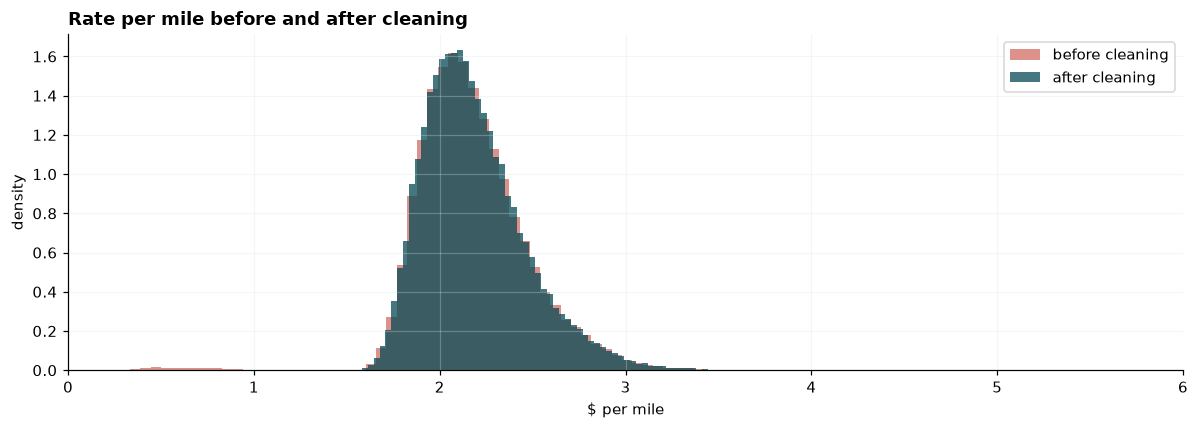

In [28]:
before = train["posted_rate"] / train["distance"]
after = train_clean["posted_rate"] / train_clean["distance"]

print(pd.DataFrame({
    "before": before.describe(),
    "after": after.describe(),
}).round(3))

plt.figure(figsize=(11, 4))
plt.hist(before, bins=250, alpha=0.55, color="#C0392B", density=True, label="before cleaning")
plt.hist(after, bins=80, alpha=0.75, color=ACCENT, density=True, label="after cleaning")
plt.xlim(0, 6)
plt.title("Rate per mile before and after cleaning", loc="left", fontweight="bold")
plt.xlabel("$ per mile"); plt.ylabel("density")
plt.legend()
save("02_cleaning_effect")
plt.show()